# Atividade 1 -- Tópicos para Computação 1 - 2026.1

- Escola Superior de Tecnologia
- Profa. Dra. Elloá B. Guedes (ebgcosta@uea.edu.br)
- www.elloaguedes.com
- github.com/elloa
- Data: 03 de março de 2026

## Descrição

A atividade consiste em usar um extrator de bordas clássico, o filtro Sobel, em duas imagens, visualizando o resultado e construindo o mapa/vetor de características resultante dessa extração. Visa ilustrar o processo manual e as operações matemáticas envolvidas em algoritmos extratores de características tradicionais, bem como introduzir competências técnicas e tecnológicas para realização de operações como a convolução em ambiente computacional.

## Prazos importantes

- Data de entrega: 06/03/2026
- Modo de entrega: Google Classroom
- Estratégia de desenvolvimento: Duplas


In [3]:
## Espaço para importar bibliotecas

import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F  

### Abrir imagem

Utilizando o pacote opencv (cv2) e a função imread, abra uma imagem de sua preferência. A imagem deve ser aberta em tons de cinza Como exemplo, há as imagens 'badbunny' e 'deepfake'. Em seguida, visualize a imagem após a abertura.

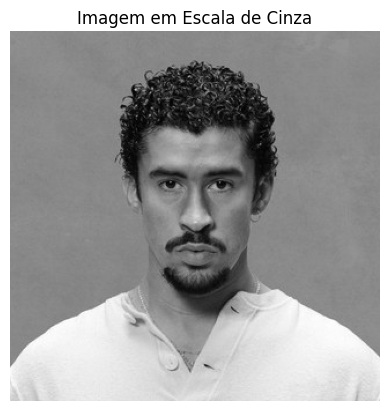

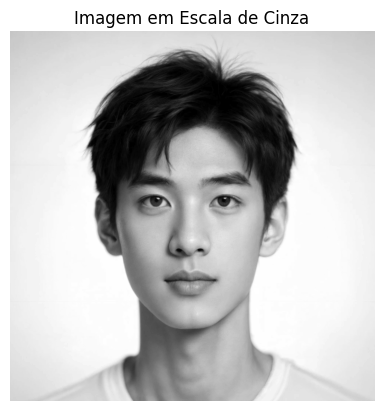

In [12]:
# Lê a imagem usando OpenCV.
img = cv2.imread('badbunny.jpeg') # Guarda a imagem em um array tridimensional (altura, largura, 3 canais(RGB)) com o Numpy.

#Converte a imagem BGR para escala de cinza, resultando em uma matriz 2D.
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) 

# Plotar a imagem em escala de cinza usando Matplotlib.
plt.imshow(gray, cmap='gray')
plt.title("Imagem em Escala de Cinza")
plt.axis('off')
plt.show()

# Mesmo processo para a imagem do deepfake.
img2 = cv2.imread('deepfake.png')

gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)


plt.imshow(gray2, cmap='gray')
plt.title("Imagem em Escala de Cinza")
plt.axis('off')
plt.show()

In [ ]:
gray.dtype # O tipo de dado da matriz é uint8, que é um tipo de inteiro sem sinal de 8 bits, com valores variando de 0 a 255.

dtype('uint8')

A Mudança na Estrutura (Shape)


- Antes (RGB/BGR): O array era 3D, com o shape (altura, largura, 3). O número 3 representa os três canais (Vermelho, Verde e Azul).


- Depois (Cinza): O array passa a ser 2D, com o shape (altura, largura). A terceira dimensão desaparece porque você não precisa mais de três valores para descrever a cor; apenas um valor de intensidade basta.


## Conversão da imagem

Para que a imagem possa ser processada com o Pytorch, ela precisa ser um tensor de 4 dimensões.

Esse tensor possui a seguinte estrutura [B, C, H, W], em que:
- Batch: denota quantas imagens estão sendo processadas de uma vez (B = 1).
- Channel: denota quantos canais de cor (C = 1 para Cinza, C = 3 para RGB).
- Height: altura da imagem em pixels.
- Width: largura da imagem em pixels.

Use o comando:

img_tensor = torch.from_numpy(img).float().unsqueeze(0).unsqueeze(0)

1. torch.from_numpy(img): Converte a matriz do NumPy do Opencv em um tensor do PyTorch
2. float(): converte de uint8 para float
3. unsqueeze(0): adiciona 1 dimensão, i.e., [1, H, W]
4. unsqueeze(0): adiciona outra dimensão, i.e., [1, 1, H, W]

Ao final, temos o tensor desejado.   
Imprima o tipo e sua forma (shape)  
Verifique as dimensões da imagem  

In [ ]:
# Imgem do Bad Bunny convertida para tensor do PyTorch, com tipo de dado float32 e dimensões (1, 1, altura, largura).
img_tensor = torch.from_numpy(gray).float().unsqueeze(0).unsqueeze(0)

print(img_tensor.dtype)
print(img_tensor.shape)


torch.float32
torch.Size([1, 1, 320, 320])


In [ ]:
# Imgem do deepfake convertida para tensor do PyTorch, com tipo de dado float32 e dimensões (1, 1, altura, largura).
img_tensor2 = torch.from_numpy(gray2).float().unsqueeze(0).unsqueeze(0)

print(img_tensor2.dtype)
print(img_tensor2.shape)

torch.float32
torch.Size([1, 1, 672, 662])


## Filtro Sobel

O filtro Sobel é uma operação utilizada em processamento de imagem, aplicada sobretudo em algoritmos de detecção de contornos. Ele calcula o gradiente da intensidade da imagem em cada ponto, dando a direcção da maior variação de claro para escuro e a quantidade de variação nessa direcção. Assim, obtém-se uma noção de como varia a luminosidade em cada ponto, de forma mais suave ou abrupta. Com isto consegue-se estimar a presença de uma transição claro-escuro e de qual a orientação desta. Como as variações claro-escuro intensas correspondem a fronteiras bem definidas entre objectos, consegue-se fazer a detecção de contornos.

O Filtro Sobel utiliza duas matrizes $3 \times 3$ que são convoluídas com a imagem original $A$ para calcular a magnitude e a direção do gradiente, da seguinte forma:


$$
\mathbf{G_x} = \begin{bmatrix} 
-1 & 0 & +1 \\ 
-2 & 0 & +2 \\ 
-1 & 0 & +1 
\end{bmatrix} * \mathbf{A} 
\quad \text{e} \quad 
\mathbf{G_y} = \begin{bmatrix} 
+1 & +2 & +1 \\ 
0 & 0 & 0 \\ 
-1 & -2 & -1 
\end{bmatrix} * \mathbf{A}
$$

Portanto a magnitude, $\mathbf{G}$, e a direcção, $\mathbf{\Theta}$, do gradiente são dados por:

$$
\begin{aligned}
\mathbf{G} &= \sqrt{\mathbf{G_x}^2 + \mathbf{G_y}^2} \\
\mathbf{\Theta} &= \arctan\left(\frac{\mathbf{G_y}}{\mathbf{G_x}}\right)
\end{aligned}
$$


### Definição dos tensores para as matrizes do Filtro Sobel

Para proceder com a aplicação do Filtro Sobel, crie dois tensores (1,1,3,3) com as matrizes $K_x$ e $K_y$ dadas a seguir:

$$
K_x = \begin{bmatrix} 
-1 & 0 & 1 \\ 
-2 & 0 & 2 \\ 
-1 & 0 & 1 
\end{bmatrix}
$$

$$K_y = \begin{bmatrix} 
+1 & +2 & +1 \\ 
0 & 0 & 0 \\ 
-1 & -2 & -1 
\end{bmatrix}
$$

In [16]:
def np2tensor(kernel):
    return torch.from_numpy(np.array(kernel)).float().unsqueeze(0).unsqueeze(0)

In [17]:
Kx = [[-1,  0,  1],
      [-2,  0,  2],
      [-1,  0,  1]]

Ky = [[ 1,  2,  1],
      [ 0,  0,  0],
      [-1, -2, -1]]

Kx_tensor = np2tensor(Kx)
Ky_tensor = np2tensor(Ky)

### Entendendo a Convolução

No contexto de processamento de imagens e visão computacional, a convolução é uma operação matemática em que uma pequena matriz, chaamda filtro ou kernel é "deslizada" sobre a imagem original para extrair características específicas.

- Kernel (Filtro): É uma matriz pequena (como o $G_x$ e $G_y$ no filtro Sobel) que contém pesos matemáticos definidos para detectar padrões
- Operação de convolução: Em cada posição da imagem, o kernel é sobreposto aos pixels da imagem. Multiplica-se cada peso do kernel pelo valor do pixel correspondente e somam-se todos esses resultados.
- Mapa de Características: O resultado dessa soma torna-se um único pixel na nova imagem (o "feature map"). Esse novo valor indica a presença ou a força da característica naquele local exato.

#### Exercício de Convolução Manual

Considere a matriz da imagem $\mathbf{M}$ e o filtro $\mathbf{F}$ a seguir:

$$
\mathbf{M} = \begin{bmatrix} 
10 & 10 & 0 & 0 \\ 
10 & 10 & 0 & 0 \\ 
10 & 10 & 0 & 0 \\ 
10 & 10 & 0 & 0 
\end{bmatrix}
\quad , \quad
\mathbf{F} = \begin{bmatrix} 
-1 & 0 & 1 \\ 
-1 & 0 & 1 \\ 
-1 & 0 & 1 
\end{bmatrix}
$$

**Tarefa:**
Calcule o mapa de características resultante da convolução $(F * M)$. 

**Equação Auxiliar:**
$$y[i, j] = \sum_{m} \sum_{n} \mathbf{M}[i-m, j-n] \cdot \mathbf{F}[m, n]$$

In [78]:
def conv(image, kernel, stride=1, padding=0):
    """
    image  : matriz 2D (H x W)
    kernel : matriz 2D (kH x kW)
    stride : passo da convolução
    padding: quantidade de zeros ao redor
    
    retorna: mapa de características
    """

    H, W = image.shape[2:]
    kH, kW = kernel.shape[2:]

    out_h = (H + 2 * padding - kH) // stride + 1
    out_w = (W + 2 * padding - kW) // stride + 1

    output = np.zeros((out_h, out_w))

    for i in range(out_h):
        for j in range(out_w):
            soma = 0
            for m in range(kH):
                for n in range(kW):
                    soma += image[0, 0, i*stride + m, j*stride + n] * kernel[0, 0, m, n]

            output[i, j] = soma

    return output

In [79]:
M = [[10,  10,  0,  0],
     [10,  10,  0,  0],
     [10,  10,  0,  0],
     [10,  10,  0,  0]]

F = [[-1,  0,  1],
     [-1,  0,  1],
     [-1,  0,  1]]

M_tensor = np2tensor(M)
F_tensor = np2tensor(F) 

y = conv(M_tensor, F_tensor)

print("Saída da convolução:")
print(y)

Saída da convolução:
[[-30. -30.]
 [-30. -30.]]


#### Convolução no Pytorch

Utilize  
import torch.nn.functional as F  

e faça   
gx = F.conv2d(img_tensor, kx, padding=1)

Repita o mesmo para obter gy  

In [77]:
gx =F.conv2d(img_tensor, Kx_tensor, stride=1, padding=1)
gy =F.conv2d(img_tensor, Ky_tensor, stride=1, padding=1)

print(gx.shape)
print(gy.shape) 

torch.Size([1, 1, 320, 320])
torch.Size([1, 1, 320, 320])


### Magnitude do Gradiente

Calcule a magnitude do gradiente, dada como segue:

$$
\mathbf{G} = \sqrt{\mathbf{G_x}^2 + \mathbf{G_y}^2}
$$ 

Use a função torch.sqrt

In [80]:
magnitude = torch.sqrt(gx**2 + gy**2)


### Orientação do gradiente

A orientação do  gradiente é dada por:

$$\mathbf{\Theta} = \arctan\left(\frac{\mathbf{G_y}}{\mathbf{G_x}}\right)$$

Use a função torch.atan2 e converta para graus, multiplicando por $180/\pi$
- Para $\pi$, use a constante do numpy

In [81]:
theta = torch.atan2(gy, gx)*180/np.pi

### Visualização do Resultado

- Para visualizar, converta os tensores para array numpy 2D. 
- Normalize a magnitude para o intervalo $[0,255]$
- Utilize o espaço de cores hsv para mostrar a orientação do gradiente
- Exiba os resultados da magnitude e da orientação ao lado da imagem original, de forma comparativa

In [82]:
mag_np = magnitude[0, 0].detach().cpu().numpy()
theta_np = theta[0, 0].detach().cpu().numpy()
original_np = img_tensor[0, 0].detach().cpu().numpy()

In [91]:
mag_norm = mag_np / mag_np.max()
mag_uint8 = (mag_norm * 255).astype(np.uint8)

In [88]:
theta_mapped = (theta_np + 180) / 360   # agora em [0,1]
theta_hue = (theta_mapped * 179).astype(np.uint8)

In [98]:
hsv = np.zeros((mag_uint8.shape[0], mag_uint8.shape[1], 3), dtype=np.uint8)

hsv[..., 0] = theta_hue     # Hue = orientação
hsv[..., 1] = 255           # Saturação máxima
hsv[..., 2] = mag_uint8     # Value = magnitude

# Converter HSV → RGB para matplotlib
orientation_rgb = cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB)

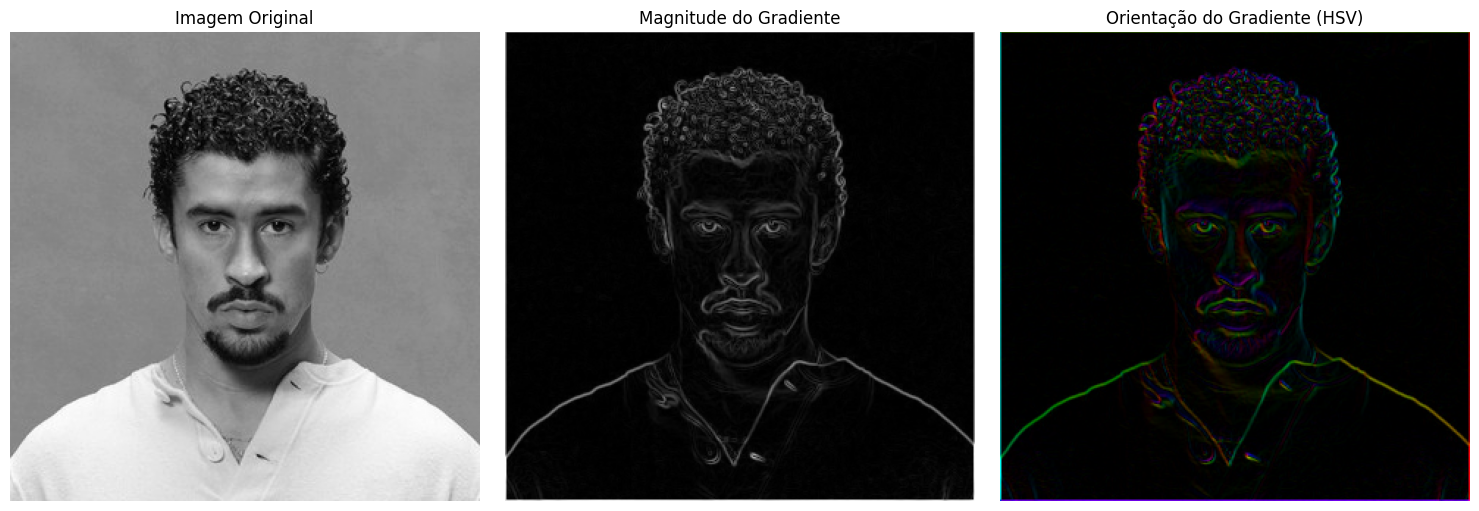

In [99]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.title("Imagem Original")
plt.imshow(original_np, cmap='gray')
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Magnitude do Gradiente")
plt.imshow(mag_uint8, cmap='gray')
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Orientação do Gradiente (HSV)")
plt.imshow(orientation_rgb)
plt.axis("off")

plt.tight_layout()
plt.show()

## Construa o vetor de características de Sobel

Observe que temos quatro matrizes além da imagem original (são elas, Gx, Gy, G e Theta). Observe que temos muito mais informação do que inicialmente começamos. Precisamos de um vetor de características global, que captura a essência das características da imagem:

### Flatten

Para obter um vetor (1D), precisamos "planificar" a matriz (2D):  
feat_magnitude = g.cpu().numpy().flatten()

### Dados Estatísticos

O vetor de características será obtido a partir de dados estatísticos da magnitude:
1. Calcule a média da magnitude: Indica a "quantidade" geral de bordas, de tal modo que uma imagem com muitas linhas terá uma média alta.
2. Calcule o desvio padrão da magnitude: Indica o contraste das bordas, isto é, diz se as bordas são todas parecidas ou se há grandes variações de intensidade.
3. Máximo: Identifica a borda mais forte encontrada na imagem.

### Concatenação

Concatene os vetores resultantes (magnitude e dados estatísticos), produzindo uma espécie de resumo das características da imagem avaliadas por Sobel

In [103]:
feat_magnitude = magnitude[0, 0].cpu().numpy().flatten()

In [104]:
mean_mag = np.mean(feat_magnitude)
std_mag  = np.std(feat_magnitude)
max_mag  = np.max(feat_magnitude)

# 4️⃣ Vetor estatístico
feat_stats = np.array([mean_mag, std_mag, max_mag])

# 5️⃣ Concatenação
feature_vector = np.concatenate([feat_magnitude, feat_stats])

print("Tamanho do vetor final:", feature_vector.shape)

Tamanho do vetor final: (102403,)


In [105]:
feature_vector = np.array([mean_mag, std_mag, max_mag])

### Argumente

O vetor de características resultante possui maior dimensão do que a imagem original, além de ter demandado processamento para ser obtido. Como ele pode ser útil em um contexto prático em uma tarefa de Visão Computacional? O esforço realizado vale a pena?

### Resposta Formal para a Pergunta

Vetores de características extraídos de imagens, apesar de aumentarem a dimensão dos dados e exigirem processamento adicional, são fundamentais em tarefas de Visão Computacional. Eles capturam informações relevantes da imagem, como bordas, texturas e padrões estruturais, que são mais informativas do que os pixels brutos.

Essa representação facilita a identificação, classificação e comparação entre imagens, além de tornar os modelos mais robustos a variações de iluminação, posição e ruído.

Além disso, vetores de características permitem a aplicação eficiente de algoritmos de aprendizado de máquina, como SVM e redes neurais, que dependem de representações discriminativas dos dados.

Portanto, embora exista um custo computacional adicional para extrair essas características, o ganho em desempenho e capacidade de generalização torna esse esforço vantajoso em aplicações práticas, como reconhecimento facial, detecção de objetos e análise de imagens médicas.

### Resposta da Pergunda para a Apresentação

- **O que são**
  - Representações numéricas extraídas de imagens.
  - Capturam **informações relevantes** como bordas, texturas e padrões estruturais.
  - São mais informativas que **pixels brutos**.

- **Por que usar**
  - Facilitam **identificação, classificação e comparação** entre imagens.
  - Tornam os modelos **mais robustos** a variações de:
    - iluminação
    - posição
    - ruído

- **Uso em Machine Learning**
  - Permitem aplicar algoritmos como:
    - **SVM**
    - **Redes neurais**
  - Esses modelos dependem de **representações discriminativas** dos dados.

- **Custo vs Benefício**
  - Existe **custo computacional** para extrair as características.
  - Porém, há **ganho em desempenho e generalização** dos modelos.

- **Aplicações práticas**
  - **Reconhecimento facial**
  - **Detecção de objetos**
  - **Análise de imagens médicas**

- **Conclusão**
  - Apesar do processamento adicional, **vetores de características tornam a análise de imagens mais eficiente e precisa**, sendo fundamentais para aplicações reais de Visão Computacional.